# HAETAE 축 A — 하드웨어 클럭글리치 T2 (독립 노트북)

무방어 baseline(+대응기법 3종)에 **실제 클럭글리치**로 T2(+y 스킵)를 유발 → **결함 응답 z1의 s1 복원율**로 누설 판정.
`Lab_HAETAE_F4_FullSign_v1`(축 B / EXP1~6)과 **독립**. 이 노트북만 위→아래로 실행.

**핵심 설계(디버깅으로 확정):**
1. **트리거=공격지점**: 펌웨어 `T` 명령으로 트리거를 특정 연산(기본 ADDY=T2)에만 발생 → 윈도우 축소 → 정밀 타격. (리셋 시 초기화되므로 매 리셋 후 재전송)
2. **width sweet spot ≈ 50**(AES 검증에서 확정). width/offset 정수.
3. `glitch_once`는 `ext_single`로 글리치 자동발사 → **시리얼을 먼저 읽고 capture는 뒤에**(capture 타임아웃 간섭 방지).
4. **LEAK 판정 = s1 복원율(agreement) ≥ LEAK_TH**. HW 글리치는 명령어 1개만 교란해 LEAK_T2와 바이트일치가 거의 없으므로 exact 다이제스트로 판정하지 않음.

**순서:** EXP7-a(셋업) → EXP7-b2(width 밴드 진단) → EXP7-b(랜덤 탐색) → EXP7-c(정밀화) → EXP7-d(4변형 비교).
전제: BUILD된 `haetae-*-FSIM-CW308_STM32F4.hex`(트리거 펌웨어)가 펌웨어 폴더에 존재. ⚠ 서명 1회 ~8초.

In [9]:
# ===== EXP7-a: 단독 부트스트랩 + '공격지점=트리거지점' 셋업 =====
%matplotlib inline
SCOPETYPE='OPENADC'; PLATFORM='CW308_STM32F4'; CRYPTO_TARGET='NONE'; SS_VER='SS_VER_1_1'
import chipwhisperer as cw
import numpy as np, time, struct, csv, collections, logging, random
logging.getLogger('ChipWhisperer').setLevel(logging.ERROR)
try:
    scope
except NameError:
    scope = cw.scope(name='Husky')
%run "../../Setup_Scripts/Setup_Generic.ipynb"

scope.clock.clkgen_freq = 7.37e6; scope.clock.adc_mul = 1; scope.io.hs2 = 'clkgen'
time.sleep(0.2)
import importlib, haetae_recover; importlib.reload(haetae_recover)
from haetae_recover import attack_recover

FW = '../../../firmware/mcu/simpleserial-haetae/'
FL = {'NONE':0,'SEED':1,'SIGNBIT':2,'UNPACK':3,'LSB':4,'CS':5,'ADDY':6,'REJECT':7}
GOLDEN  = bytes.fromhex('ba9f152c607b207fc6512635ba11388c')   # 무결함 서명(결정론)
LEAK_T2 = bytes.fromhex('63ff5ebfaa6263739651890939cccb48')   # T2 클린스킵 누설(+y 전체 skip → z=LN·c·s1)
LEAK_TH = 0.99                # LEAK 판정 임계(s1 복원율). 부분누설만 보려면 낮춰 재실행
SIGN_MS = 15000              # ★ full-sign 응답 대기(ms). 서명 ~8초라 넉넉히. glitch_once 의 정상프레임 read timeout
TRIG_POINT = FL['ADDY']       # ★ 공격지점=트리거지점. ADDY=T2(+y) / CS=T1 / REJECT=RB / 0=전체

def ss_echo(timeout=3000):
    target.flush(); target.simpleserial_write('e', bytearray())
    r = target.simpleserial_read('r', 16, timeout=timeout); return bytes(r) if r else None
def ss_sign(timeout=90000):
    target.flush(); target.simpleserial_write('p', bytearray([0]*16))
    r = target.simpleserial_read('r', 16, timeout=timeout); return bytes(r) if r else None
def set_fault(line, oneshot=0, checkskip=0):
    target.flush(); target.simpleserial_write('f', bytes([line, oneshot, checkskip]))
    return target.simpleserial_read('r', 1, timeout=3000)
def ss_trig(pt):
    target.flush(); target.simpleserial_write('T', bytes([pt]))
    return target.simpleserial_read('r', 1, timeout=3000)
def flash(hexname):
    cw.program_target(scope, prog, FW + hexname); reset_target(scope); time.sleep(0.5); target.flush()
def recover_target():                       # 리셋 후 트리거지점 재설정(리셋이 g_trig_line 초기화)
    reset_target(scope); time.sleep(0.5); target.flush()
    try: ss_trig(TRIG_POINT)
    except Exception: pass

# 플래시(clean clock) + SW결함 OFF + 워밍업(키생성) + GOLDEN 확인
scope.io.hs2 = 'clkgen'
flash('haetae-baseline-FSIM-{}.hex'.format(PLATFORM))
set_fault(FL['NONE'], 0, 0)
g = ss_sign()
print('echo:', (ss_echo() or b'').hex()[:8], '| sign:', g.hex() if g else None)
assert g == GOLDEN, 'GOLDEN 불일치! 펌웨어/키 확인 (volatile 가드 적용 후 BUILD 셀로 재빌드했는지 확인)'
pt_name = [k for k,v in FL.items() if v==TRIG_POINT][0]
print('trig set:', (ss_trig(TRIG_POINT) or b'').hex(), '( 지점 =', pt_name, ')')

# (1) 트리거 윈도우 측정 — TRIG_POINT 연산만 → 작게
scope.adc.basic_mode='rising_edge'
try: scope.trigger.triggers='tio4'
except Exception: pass
scope.adc.timeout = 12
scope.arm(); target.simpleserial_write('p', bytearray([0]*16))
to = scope.capture(); WIN = int(scope.adc.trig_count)
target.simpleserial_read('r', 16, timeout=20000)
print('WIN(%s만) = %d 타겟 사이클 | timeout? %s' % (pt_name, WIN, to))

# (2) 클럭글리치 모드 + 리셋 + 트리거지점 재설정
scope.glitch.enabled = True
scope.glitch.clk_src = 'pll'; scope.glitch.output = 'clock_xor'
scope.glitch.trigger_src = 'ext_single'; scope.glitch.repeat = 1
scope.io.hs2 = 'glitch'; scope.adc.timeout = 3
time.sleep(0.2); reset_target(scope); time.sleep(0.5); target.flush(); ss_trig(TRIG_POINT)
PSS = scope.glitch.phase_shift_steps
print('glitch 모드 | echo:', (ss_echo() or b'').hex()[:8], '| PSS =', PSS)

def set_glitch(delay, width, offset):
    scope.glitch.ext_offset = int(delay); scope.glitch.width = int(width); scope.glitch.offset = int(offset)

def glitch_once(read_timeout=SIGN_MS):
    # ext_single → 글리치는 하드웨어 트리거에 자동 발사. 시리얼 먼저 읽고 capture는 뒤(정리용).
    if scope.adc.state:                     # 직전 샷 트리거가 아직 high = 크래시. arm 전 빠른 리셋
        recover_target()
    scope.arm(); target.flush(); target.simpleserial_write('p', bytearray([0]*16))
    # ★ 핵심: 정상 프레임 읽기 timeout 에 서명시간(≈8초)을 줘야 함. 기본 250ms면 매번 오독→mute.
    #   glitch_timeout 은 프레임이 깨졌을 때(크래시) 잔여 바이트 수거용(짧게).
    r = target.simpleserial_read_witherrors('r', 16, timeout=read_timeout, glitch_timeout=1500)
    try: scope.capture()
    except Exception: pass
    if (not r['valid']) or r['payload'] is None:
        if ss_echo(800) is None: recover_target()
        else: target.flush()
        return 'mute', None
    p = bytes(r['payload'])
    return ('normal', p) if p == GOLDEN else (('success', p) if p == LEAK_T2 else ('other', p))

def recover_agreement():                    # 결함 응답 z1 → s1 복원율(0~1). 느림(z1/s1/c 스트리밍) → 후보에만 호출
    try: return float(attack_recover(target)['agreement'])
    except Exception: return 0.0

def classify_shot(g, p, recover_other=False):
    """glitch_once 결과 → (cls, agr). success(=exact LEAK_T2, +y 전체 clean skip)만 복원 확정.
       recover_other=True 면 'other'도 복원해 부분누설(agr>=LEAK_TH)을 LEAK로 승격."""
    if g == 'mute':    return 'mute', None
    if g == 'normal':  return 'golden', None
    if g == 'success': return 'LEAK', recover_agreement()
    if recover_other:
        agr = recover_agreement()
        return ('LEAK' if agr >= LEAK_TH else 'faulty'), agr
    return 'faulty', None

print('준비 완료 — EXP7-b2(진단) 또는 EXP7-b(랜덤) 실행')

INFO: Found ChipWhisperer😍


(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:704) Target clock may drop; you may need to reset your target.


scope.clock.clkgen_freq                  changed from 7371428.571428572         to 7363636.363636363        
scope.clock.adc_mul                      changed from 1                         to 4                        
scope.clock.adc_freq                     changed from 7371428.571428572         to 29454545.454545453       
scope.clock.adc_rate                     changed from 7371428.571428572         to 29454545.454545453       
scope.io.hs2                             changed from glitch                    to clkgen                   
scope.glitch.enabled                     changed from True                      to False                    
scope.glitch.mmcm_locked                 changed from True                      to False                    


(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:704) Target clock may drop; you may need to reset your target.


Detected known STMF32: STM32F40xxx/41xxx
Extended erase (0x44), this can take ten seconds or more
Attempting to program 25895 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 25895 bytes
echo: a0a1a2a3 | sign: ba9f152c607b207fc6512635ba11388c
trig set: 06 ( 지점 = ADDY )
WIN(ADDY만) = 15568 타겟 사이클 | timeout? False
glitch 모드 | echo: a0a1a2a3 | PSS = 4592
준비 완료 — EXP7-b2(진단) 또는 EXP7-b(랜덤) 실행


In [10]:
# 진단: 글리치 모드에서 (1) 무글리치 full-sign, (2) width=0 글리치 5회
print('no-glitch full sign (glitch mode):', (ss_sign() or b'').hex())   # GOLDEN 이어야 정상
scope.glitch.repeat = 1
for _ in range(5):
    set_glitch(0, 0, 0)          # width=0 = 사실상 글리치 없음
    print(glitch_once(read_timeout=12000))


no-glitch full sign (glitch mode): ba9f152c607b207fc6512635ba11388c
('normal', b'\xba\x9f\x15,`{ \x7f\xc6Q&5\xba\x118\x8c')
('normal', b'\xba\x9f\x15,`{ \x7f\xc6Q&5\xba\x118\x8c')
('normal', b'\xba\x9f\x15,`{ \x7f\xc6Q&5\xba\x118\x8c')
('normal', b'\xba\x9f\x15,`{ \x7f\xc6Q&5\xba\x118\x8c')
('normal', b'\xba\x9f\x15,`{ \x7f\xc6Q&5\xba\x118\x8c')


captured 16368 samples | WIN(trig_count)=124544 | timeout=False


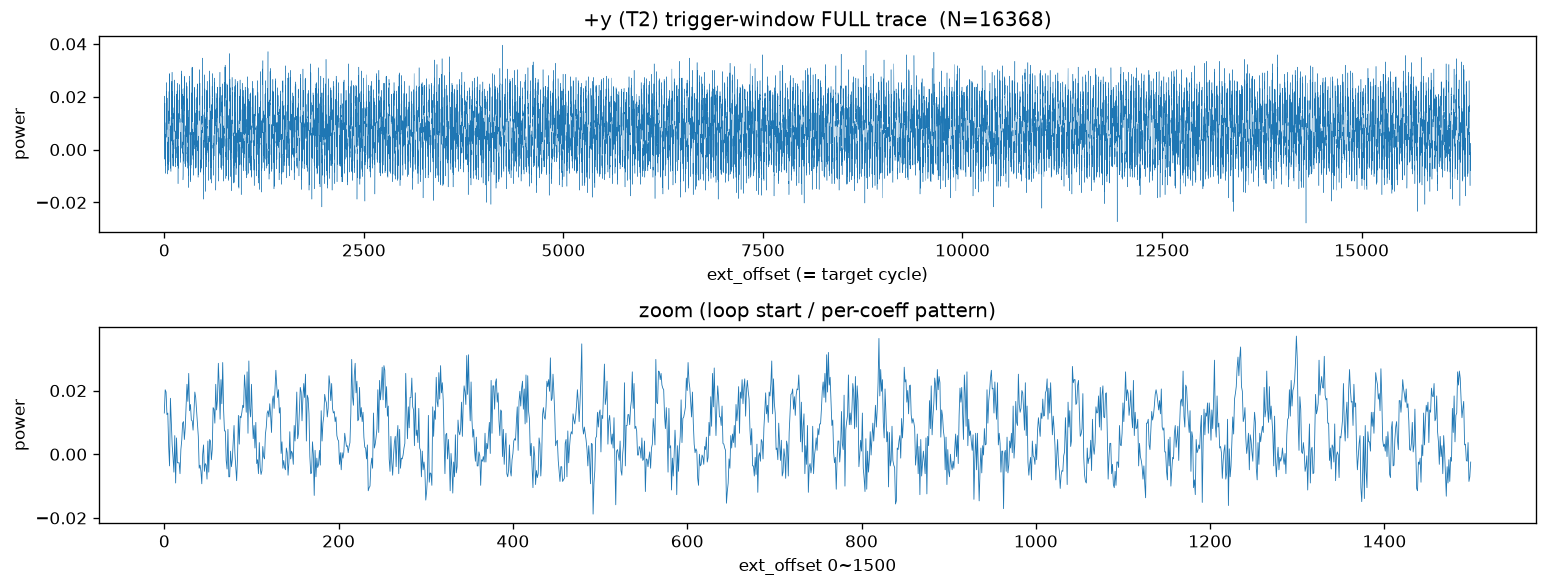

saved: fig_exp7_t2_trace.png, exp7_t2_trace.npy | glitch mode restored
-> 규칙적 반복 구간 = +y 루프. 그 구간의 ext_offset 범위를 EXP7-b / 스윕 목표로 사용.


In [11]:
# ===== EXP7-b0: T2 시점 확정 — +y(ADDY) 트리거창 파워트레이스 =====
# 트리거가 +y 만 감싸므로 이 트레이스 = +y 구간 전체. 규칙적 반복 = 다항식벡터 덧셈 루프
# (polyfixvecl_add: L*N=1024 계수 -> polyfixveck_add: K*N=512 계수). adc_mul=1 -> sample = target cycle = ext_offset.
import matplotlib.pyplot as plt
scope.io.hs2 = 'clkgen'                                     # 클린 클럭으로 깨끗한 트레이스
reset_target(scope); time.sleep(0.3); target.flush(); ss_trig(TRIG_POINT)
old_samples = scope.adc.samples
scope.adc.samples = int(min(WIN + 800, 60000))             # +y 창 전체 캡처
scope.adc.timeout = 12
scope.arm(); target.simpleserial_write('p', bytearray([0]*16))
_to = scope.capture(); target.simpleserial_read('r', 16, timeout=20000)
wave = scope.get_last_trace()
print('captured %d samples | WIN(trig_count)=%d | timeout=%s' % (len(wave), int(scope.adc.trig_count), _to))

fig, ax = plt.subplots(2, 1, figsize=(13, 5), dpi=120)
ax[0].plot(wave, lw=0.25); ax[0].set_xlabel('ext_offset (= target cycle)'); ax[0].set_ylabel('power')
ax[0].set_title('+y (T2) trigger-window FULL trace  (N=%d)' % len(wave))
z = wave[:min(1500, len(wave))]
ax[1].plot(z, lw=0.5); ax[1].set_xlabel('ext_offset 0~%d' % len(z)); ax[1].set_ylabel('power')
ax[1].set_title('zoom (loop start / per-coeff pattern)')
fig.tight_layout(); fig.savefig('fig_exp7_t2_trace.png'); plt.show()

np.save('exp7_t2_trace.npy', np.asarray(wave))             # 재현/논문용 저장
scope.adc.samples = old_samples; scope.io.hs2 = 'glitch'; scope.adc.timeout = 3   # 글리치 모드 복원
reset_target(scope); time.sleep(0.3); target.flush(); ss_trig(TRIG_POINT)
print('saved: fig_exp7_t2_trace.png, exp7_t2_trace.npy | glitch mode restored')
print('-> 규칙적 반복 구간 = +y 루프. 그 구간의 ext_offset 범위를 EXP7-b / 스윕 목표로 사용.')


HAETAE glitch @ADDY:   0%|          | 0/150 [00:00<?, ?it/s]

(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454

DONE: {'golden': 135, 'LEAK': 0, 'faulty': 3, 'mute': 12} | best s1 복원율 = 0.0% | leak: []
* LEAK/부분누설 0 이면: 파워트레이스(EXP7-b0)로 +y 구간 확인 후 ext 범위 조정 / W_RANGE=(40,60) / N_TRIES up / 저-거부 메시지로 속도개선
saved exp7_glitch_log.csv


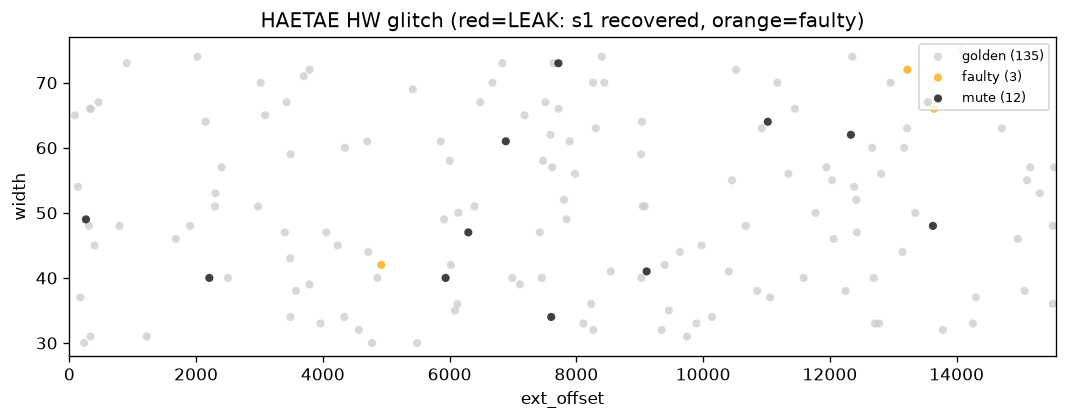

In [12]:
# ===== EXP7-b: 랜덤 글리치 탐색 — 가드(ext≈0) 집중 + 부분누설 포착 + tqdm =====
from tqdm.notebook import trange
N_TRIES  = 150
W_RANGE  = (30, 75); O_RANGE = (-15, 15); REP_POOL = [1, 1, 2]   # W: AES 검증 sweet spot(3~29 는 무효)
E_MAX    = int(WIN)    # +y 루프 전체(real HAETAE: 가드 없음 -> 루프 어디든 표적). 파워트레이스로 좁힌 구간 있으면 그 값으로
LEAK_TH  = 0.5         # ★ 부분누설도 LEAK 로 인정(HW 실현성 입증엔 충분). 정본 클레임은 0.99 로 재판정
STOP_AFTER    = 3      # LEAK 이만큼 확보하면 조기 종료
RECOVER_OTHER = True   # ★ faulty(부분/기타 결함)도 s1 복원율 계산 → 부분누설 정량화
cnt = collections.OrderedDict(golden=0, LEAK=0, faulty=0, mute=0); log=[]; leakp=[]; best_agr=0.0
bar = trange(N_TRIES, desc='HAETAE glitch @%s' % [k for k,v in FL.items() if v==TRIG_POINT][0])
for i in bar:
    w = random.randint(*W_RANGE); o = random.randint(*O_RANGE); e = random.randint(0, E_MAX); rep = random.choice(REP_POOL)
    set_glitch(e, w, o); scope.glitch.repeat = int(rep)
    g, p = glitch_once()
    cls, agr = classify_shot(g, p, recover_other=RECOVER_OTHER)   # success + faulty 도 복원
    if agr is not None: best_agr = max(best_agr, agr)
    if cls == 'LEAK':
        leakp.append((e, w, o, rep, round(agr,3) if agr is not None else None))
        bar.write('★ LEAK ext=%d w=%d o=%d rep=%d | %s | s1 복원율 %s' % (
            e, w, o, rep, ('exact LEAK_T2' if g=='success' else 'other→복원'),
            ('%.1f%%'%(100*agr)) if agr is not None else 'n/a'))
    elif agr is not None and agr > 0:   # 부분누설(LEAK_TH 미만이라도 일부 s1 복원) 표시
        bar.write('· 부분누설 ext=%d w=%d o=%d rep=%d → s1 %.1f%%' % (e, w, o, rep, 100*agr))
    cnt[cls] += 1
    log.append((int(e), int(w), int(o), int(rep), cls, ('%.3f'%agr) if agr is not None else '', p.hex() if p else ''))
    bar.set_postfix(best_s1='%.0f%%' % (100*best_agr), **cnt)
    if cnt['LEAK'] >= STOP_AFTER: bar.write('LEAK 확보 — 종료'); break
scope.glitch.repeat = 1
print('DONE:', dict(cnt), '| best s1 복원율 = %.1f%%' % (100*best_agr), '| leak:', leakp[:5])
print('* LEAK/부분누설 0 이면: 파워트레이스(EXP7-b0)로 +y 구간 확인 후 ext 범위 조정 / W_RANGE=(40,60) / N_TRIES up / 저-거부 메시지로 속도개선')
with open('exp7_glitch_log.csv','w',newline='') as f:
    wr=csv.writer(f); wr.writerow(['ext','width','offset','repeat','class','agreement','digest']); wr.writerows(log)
print('saved exp7_glitch_log.csv')

import matplotlib.pyplot as plt
CMAP = collections.OrderedDict(golden='0.8', LEAK='red', faulty='orange', mute='black')
fig, ax = plt.subplots(figsize=(9,3.6), dpi=120)
for cls,col in CMAP.items():
    pts=[(r[0],r[1]) for r in log if r[4]==cls]
    if pts:
        xs,ys=zip(*pts); ax.scatter(xs,ys,c=col,s=24,alpha=0.75,edgecolors='none',label='%s (%d)'%(cls,cnt[cls]))
ax.set_xlim(0,max(E_MAX,1)); ax.set_ylim(W_RANGE[0]-2,W_RANGE[1]+2)
ax.set_xlabel('ext_offset'); ax.set_ylabel('width'); ax.legend(loc='upper right',fontsize=8)
ax.set_title('HAETAE HW glitch (red=LEAK: s1 recovered, orange=faulty)')
fig.tight_layout(); fig.savefig('fig_exp7_map.png'); plt.show()

In [ ]:
# ===== EXP7-b1: 부분누설 누적 복구 — ext 스캔으로 계수별 y-스킵 수집 -> 누적 -> s1 =====
# real full-HAETAE: 단일 글리치는 +y(1024계수) 중 일부 계수만 y-add 를 스킵 -> 그 계수는 z1=LN*cs1(LN 배수).
# 결정론 키라 z1_normal 동일 -> ext 를 +y 루프 전체에 스캔하며 서로 다른 계수를 모아 누적 -> 768계수 완성 시 s1 복원.
# (재실행 시 acc 에 이어서 누적. 처음부터 다시 하려면 커널에서 del acc)
import importlib, haetae_recover; importlib.reload(haetae_recover)
from haetae_recover import PartialAccumulator, partial_coeffs, read_z1raw, read_cpoly, read_s1ntt
from tqdm.notebook import trange

# 0) baseline 플래시 + 결정론 정상 z1/c/참s1 확보 + 누적기 준비
scope.io.hs2 = "clkgen"; flash("haetae-baseline-FSIM-{}.hex".format(PLATFORM)); set_fault(FL["NONE"], 0, 0)
scope.io.hs2 = "glitch"; scope.adc.timeout = 3
time.sleep(0.2); reset_target(scope); time.sleep(0.5); target.flush(); ss_trig(TRIG_POINT)
scope.glitch.repeat = 1; _g = ss_sign()
z1n = read_z1raw(target); cpoly = read_cpoly(target); s1true = read_s1ntt(target)
try:
    acc
except NameError:
    acc = PartialAccumulator(cpoly, z1_normal=z1n)
print("clean sign =", (_g or b"").hex()[:8], "| GOLDEN?", _g == GOLDEN, "| start coverage =", acc.coverage())

# 1) ext 스캔 글리치 -> accepted-fault z1 에서 clean 계수 누적
N = 150; W_RANGE = (30, 75); O_RANGE = (-15, 15)
faults = 0; bar = trange(N, desc="partial-harvest")
for i in bar:
    e = int(i / N * WIN)                                   # +y 루프 전체 순차 스캔
    w = random.randint(*W_RANGE); o = random.randint(*O_RANGE); rep = random.choice([1, 1, 2])
    set_glitch(e, w, o); scope.glitch.repeat = int(rep)
    g, p = glitch_once()
    if p is not None and p != GOLDEN:                      # accepted 이면서 결함(golden 아님)
        z1f = read_z1raw(target)
        cc = partial_coeffs(z1f, z1n)                      # 이번 fault 의 clean-skip 계수(진단)
        new, cov = acc.add(z1f); faults += 1
        if len(cc):
            bar.write("fault @ext=%d: clean_coef %d (new %d) | cov(c,s1a,s1b,s1c)=%s" % (e, len(cc), new, cov))
    bar.set_postfix(faults=faults, sec=sum(acc.coverage()[1:]))
    if sum(acc.coverage()[1:]) >= 768:
        bar.write("*** 3 secret blocks complete -> recover"); break
scope.glitch.repeat = 1

# 2) 복원(완성 블록만) + 진행상황
res = acc.recover(true_s1ntt=s1true)
print("coverage (c, s1[0], s1[1], s1[2]) =", res["coverage"], "/256 each | total fault =", acc.n_add, "| sign =", acc.sign)
if "agreement" in res:
    print("*** s1 FULL recovery = %.1f%% (sign %s)" % (100 * res["agreement"], res["sign"]))
else:
    done = sum(res["coverage"][1:]); print("partial coverage %d/768 (%.1f%%) — re-run this cell to keep accumulating" % (done, 100 * done / 768))
print("[diag] fault 당 clean_coef 가 크면 소수 결함으로 복원 가능 / 0~소수면 garble -> loop-abort 표적 검토")


정밀화 중심 ext = 4921 | 후보 3개


refine:   0%|          | 0/120 [00:00<?, ?it/s]

(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454

done: {'golden': 97, 'LEAK': 0, 'faulty': 4, 'mute': 19} | best s1=0.0% | best LEAK: None


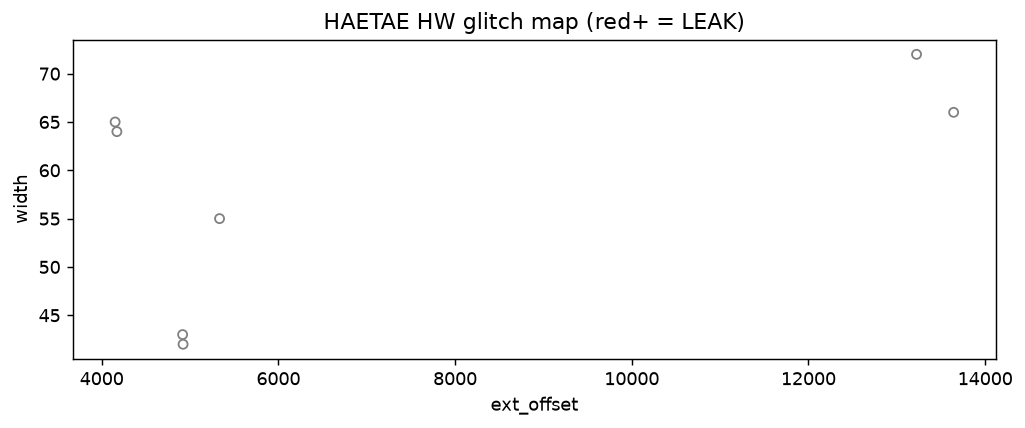

In [13]:
# ===== EXP7-c: 高복원율 ext 근처 정밀 랜덤 + s1 복원 + 맵 =====
from tqdm.notebook import trange
try: log
except NameError: log = []
cand = [r for r in log if len(r)>=6 and r[4] in ('LEAK','faulty') and r[5] not in ('',None)]
cand.sort(key=lambda r: float(r[5]), reverse=True)
base_e = int(cand[0][0]) if cand else int(WIN*0.5)
print('정밀화 중심 ext =', base_e, '| 후보 %d개' % len(cand), flush=True)
cnt = collections.OrderedDict(golden=0, LEAK=0, faulty=0, mute=0); best=None; best_agr=0.0
for _ in trange(120, desc='refine'):
    e = max(base_e + random.randint(-800,800), 0)
    w = random.randint(35,65); o = random.randint(-12,12); rep = random.choice([1,2])
    set_glitch(e, w, o); scope.glitch.repeat = int(rep)
    g, p = glitch_once()
    cls, agr = classify_shot(g, p, recover_other=True)   # 정밀화 단계: 샷 적음 → other 도 복원해 부분누설 정량화
    if agr is not None: best_agr = max(best_agr, agr)
    if cls=='LEAK':
        print('★ LEAK s1 %s (ext=%d w=%d o=%d rep=%d)'%(('%.1f%%'%(100*agr)) if agr is not None else 'n/a',e,w,o,rep))
        if best is None: best=(int(e),int(w),int(o),int(rep))
    cnt[cls]+=1
    log.append((int(e),int(w),int(o),int(rep),cls,('%.3f'%agr) if agr is not None else '', p.hex() if p else ''))
scope.glitch.repeat=1
print('done:', dict(cnt), '| best s1=%.1f%%'%(100*best_agr), '| best LEAK:', best)
with open('exp7_glitch_log.csv','w',newline='') as f:
    wr=csv.writer(f); wr.writerow(['ext','width','offset','repeat','class','agreement','digest']); wr.writerows(log)
import matplotlib.pyplot as plt
pts=[(r[0],r[1],r[4]) for r in log if len(r)>=5 and r[4] in ('LEAK','faulty')]
fig,ax=plt.subplots(figsize=(8,3.4),dpi=130)
for e,w,c_ in pts:
    if c_=='LEAK': ax.scatter(e,w,c='red',marker='+',s=120,linewidths=2)
    else: ax.scatter(e,w,facecolors='none',edgecolors='gray',s=25)
ax.set_xlabel('ext_offset'); ax.set_ylabel('width'); ax.set_title('HAETAE HW glitch map (red+ = LEAK)')
fig.tight_layout(); fig.savefig('fig_exp7_map.png'); plt.show()

Detected known STMF32: STM32F40xxx/41xxx
Extended erase (0x44), this can take ten seconds or more
Attempting to program 25895 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 25895 bytes


[baseline]:   0%|          | 0/60 [00:00<?, ?it/s]

(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 


[baseline] {'golden': 51, 'LEAK': 0, 'faulty': 1, 'mute': 8} | best s1=0.0%
Detected known STMF32: STM32F40xxx/41xxx
Extended erase (0x44), this can take ten seconds or more
Attempting to program 26103 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 26103 bytes


[double]:   0%|          | 0/60 [00:00<?, ?it/s]

...

(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 


[leeha] {'golden': 55, 'LEAK': 0, 'faulty': 1, 'mute': 4} | best s1=0.0%
Detected known STMF32: STM32F40xxx/41xxx
Extended erase (0x44), this can take ten seconds or more
Attempting to program 32151 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 32151 bytes


[irv]:   0%|          | 0/60 [00:00<?, ?it/s]

(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 
(ChipWhisperer Target WARNING|File SimpleSerial.py:454) Unexpected start to command: 


[irv] {'golden': 53, 'LEAK': 0, 'faulty': 0, 'mute': 7} | best s1=0.0%

===== 축 A HW 클럭글리치 @+y — 변형 비교 (LEAK=s1복원>=50%) =====
variant     LEAK   golden   faulty   mute  best_s1
baseline       0       51        1      8       0%
double         0       53        1      6       0%
leeha          0       55        1      4       0%
irv            0       53        0      7       0%

해석: baseline은 LEAK(s1 복원) 발생, double/leeha/irv는 LEAK=0(복원율 낮음)이면 축 A로도 대응기법 실효 입증.


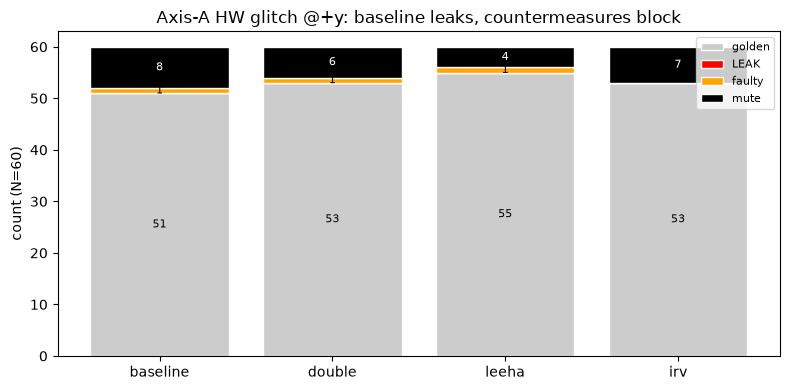

saved exp7_variants.csv + fig_exp7_variants.{png,pdf}


In [14]:
# ===== EXP7-d: 축 A 변형 비교 (baseline/double/leeha/irv, 복원율 기반) + 막대그래프 =====
from tqdm.notebook import trange
assert TRIG_POINT == FL['ADDY'], 'TRIG_POINT=FL[ADDY]로 EXP7-a 실행 필요'
N_PER    = 60
W_RANGE  = (35,70); O_RANGE=(-15,15); REP_POOL=[1,1,2]
E_MAX    = int(WIN*1.05) if WIN>0 else 4000
VARIANTS = ['baseline','double','leeha','irv']
CLASSES  = ['golden','LEAK','faulty','mute']
CCOL     = {'golden':'0.8','LEAK':'red','faulty':'orange','mute':'black'}
summary = collections.OrderedDict(); glog=[]
for V in VARIANTS:
    scope.io.hs2='clkgen'
    flash('haetae-{}-FSIM-{}.hex'.format(V, PLATFORM))
    set_fault(FL['NONE'],0,0)
    scope.io.hs2='glitch'; scope.adc.timeout=3
    time.sleep(0.2); reset_target(scope); time.sleep(0.5); target.flush(); ss_trig(TRIG_POINT)
    if ss_sign() is None: recover_target(); ss_sign()
    cnt=collections.OrderedDict(golden=0,LEAK=0,faulty=0,mute=0); best_agr=0.0
    bar=trange(N_PER, desc='[%s]'%V)
    for i in bar:
        w=random.randint(*W_RANGE); o=random.randint(*O_RANGE); e=random.randint(0,E_MAX); rep=random.choice(REP_POOL)
        set_glitch(e,w,o); scope.glitch.repeat=int(rep)
        g,p=glitch_once()
        cls, agr = classify_shot(g, p, recover_other=True)   # 변형 비교: other 도 복원해 실제 s1 누설 여부 엄격 확인
        if agr is not None: best_agr=max(best_agr,agr)
        if cls=='LEAK': bar.write('  [%s] LEAK s1 %s (ext=%d w=%d)'%(V,('%.1f%%'%(100*agr)) if agr is not None else 'n/a',e,w))
        cnt[cls]+=1; glog.append((V,e,w,o,rep,cls,('%.3f'%agr) if agr is not None else ''))
        bar.set_postfix(best_s1='%.0f%%'%(100*best_agr), **cnt)
    scope.glitch.repeat=1; summary[V]=dict(cnt); summary[V]['best_s1']=best_agr
    print('[%s] %s | best s1=%.1f%%'%(V,dict(cnt),100*best_agr), flush=True)

print('\n===== 축 A HW 클럭글리치 @+y — 변형 비교 (LEAK=s1복원>=%.0f%%) ====='%(100*LEAK_TH))
print('%-9s %6s %8s %8s %6s %8s'%('variant','LEAK','golden','faulty','mute','best_s1'))
for V,s in summary.items():
    print('%-9s %6d %8d %8d %6d %7.0f%%'%(V,s['LEAK'],s['golden'],s['faulty'],s['mute'],100*s['best_s1']))
print('\n해석: baseline은 LEAK(s1 복원) 발생, double/leeha/irv는 LEAK=0(복원율 낮음)이면 축 A로도 대응기법 실효 입증.')

import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(8,4)); x=range(len(VARIANTS)); bottom=[0]*len(VARIANTS)
for cls in CLASSES:
    vals=[summary[V][cls] for V in VARIANTS]
    ax.bar(x,vals,bottom=bottom,color=CCOL[cls],label=cls,edgecolor='white')
    for xi,(vv,bb) in enumerate(zip(vals,bottom)):
        if vv: ax.text(xi,bb+vv/2,str(vv),ha='center',va='center',color=('white' if cls in ('LEAK','mute') else 'black'),fontsize=8)
    bottom=[b+v for b,v in zip(bottom,vals)]
ax.set_xticks(list(x)); ax.set_xticklabels(VARIANTS); ax.set_ylabel('count (N=%d)'%N_PER)
ax.legend(loc='upper right',fontsize=8); ax.set_title('Axis-A HW glitch @+y: baseline leaks, countermeasures block')
fig.tight_layout(); fig.savefig('fig_exp7_variants.png',dpi=130); fig.savefig('fig_exp7_variants.pdf'); plt.show()
with open('exp7_variants.csv','w',newline='') as f:
    wr=csv.writer(f); wr.writerow(['variant','LEAK','golden','faulty','mute','best_s1'])
    for V,s in summary.items(): wr.writerow([V,s['LEAK'],s['golden'],s['faulty'],s['mute'],'%.3f'%s['best_s1']])
    wr.writerow([]); wr.writerow(['variant','ext','width','offset','repeat','class','agreement']); wr.writerows(glog)
print('saved exp7_variants.csv + fig_exp7_variants.{png,pdf}')

## 해석 / 운영

- **판정**: `LEAK`=결함 응답에서 s1 복원율 ≥ `LEAK_TH`(기본 0.99). `faulty`=결함이나 복원 낮음. `golden`=무영향. `mute`=무응답(크래시).
- **진행바 `best_s1`** 를 보세요. 높으면 실제 누설, 낮게 머물면 단일 글리치가 +y를 부분 교란만 하는 것.
- LEAK이 안 나오면: `LEAK_TH` 낮춰 부분누설 관찰 / `EXP7-a`의 `TRIG_POINT=FL['CS']`(T1) 로 바꿔 재실행 / width·ext 범위 조정.
- **운영 팁**: mute 폭주 시 타겟이 꼬입니다. **커널 재시작 → EXP7-a → (즉시) EXP7-b2/b** 가 항상 깨끗한 출발점.
- 산출물: `exp7_glitch_log.csv`, `exp7_variants.csv`, `fig_exp7_map.png`, `fig_exp7_variants.{png,pdf}`.

**주의**: `T` 트리거 명령이 있는 최신 펌웨어로 빌드된 `haetae-*-FSIM-*.hex` 필요(없으면 메인 노트북 BUILD 셀 또는 WSL make 로 재빌드).